### Problem Definition and Data Import

In [ ]:
# Importing Google Colab Drive helper and mounts my Google Drive at a specified file location.
# Such that the notebook can read and write files stored in the Drive. Mounting creates a local filesysten path to the Drive.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Setting variable for dataset location in Drive.
pathZip = "/content/drive/MyDrive/Othercomputers/My Computer/ePortfolio Projects/Food Recognition/Food_Data"

In [ ]:
# Import NumPy and Pandas
import numpy as np # Array Mathematics
import pandas as pd # Tabular Metadata

# Import Matplotlib's plotting API and OS utilities
import matplotlib.pyplot as plt # Plotting library
import os # Operating System

# Import OpenCV and Seaborn
import cv2 # Image processig library
import seaborn as sns # Aesthetic Graphical Visual Library

# Import Tensorflow and Keras
import tensorflow as tf # Machine Learning Software Library
import keras # Neural Network Software Library

# Pull Keras Model Classes
from tensorflow.keras.models import Sequential, Model # Sequenital - Layers stacked in straight line (Simple Convolutional Neural Network, CNN), Model - Functional Application Programming Interface, API, for more flexible architectures

# Import Common Layer Types
# Dense: Fully connected layers for classification head., Conv2D: Learn spatial filters for images., MaxPooling2D: Downsample to reduce spatial size and overfitting., BatchNormalization: Stabilise and accelerate training by normalising activations.
# Activation: Introduce non-linearity, LeakyReLU: Avoids "dying ReLU", Dropout: Regularisation by randomly zeroing activations, Flatten: Convert feature maps to a vector before dense layers.
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, BatchNormalization, Activation, Input, LeakyReLU, Dropout, Flatten

# Import Keras backend utilities
from tensorflow.keras import backend # Needed for low-level operations

# One-hot encoder utility
from tensorflow.keras.utils import to_categorical # Converts integer class IDs into one-hot vectors for softmax training when using categorical cross-entropy.

# Optimiser classes
# Adam: Adaptively adjusts learning rates for each parameter, using historical gradient information. SGD: Iteratively finds best model parameters. RMSprop: Dynamically adjusts learning rate for each parameter, based on moving averages.
from tensorflow.keras.optimizers import Adam, SGD, RMSprop # Controls parameter weighting during training.

# Import training model callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # EarlyStopping: stops when validation metric stops improving, preventing overfitting and saves time. ModelCheckpoint: Saves model after every epoch, thus saves best weights during training.

# Import losses and optimisers functions
from tensorflow.keras import losses, optimizers # Access loss and optimiser factories

# Import image loader that returns a Python Image Library image format
from tensorflow.keras.preprocessing.image import load_img # Loads and resizes images before converting to arrays.

# Import cv2.imshow for notebooks
from google.colab.patches import cv2_imshow #Traditional cv2.imshow does not work in notebooks; cv2_imshow displays OpenCV images.

### Loading the Data

In [ ]:
# Create Directory for the Training Data
DATADIR = '/content/drive/Othercomputers/My Computer/ePortfolio Projects/Food Recognition/Food_Data/Training' # Data file path
CATEGORIES = ['Bread', 'Soup', 'Vegetable-Fruit'] # Set Data Categories
IMG_SIZE = 150 # Set image size for uniformity and smaller image sizs, enabling larger batch sizes and preventing GPU memory issues

In [ ]:
# Create a function to create a list of the training data
# Purpose: Handle loading and preprocessing of image data.
# This may include reading image files, resizing images, normalising pixel values, and organising the data into suitable format for a machine learning model.
training_data = []

def create_training_data():
  for category in CATEGORIES:
    path = os.path.join(DATADIR, category) # Concetenate different directories for each category, formulating the file path to each one
    class_num = category # Create data class variable

    for img in os.listdir(path): # Use os library to look at every file in the path directory
      img_array = cv2.imread(os.path.join(path, img)) # Read image file and convert into usable data
      new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE)) # Create new array with image date resized to specified size
      training_data.append([new_array, class_num]) # Append training data list with the new array

In [ ]:
# Run function to go through every directory and append into a list for the training data
create_training_data()

In [ ]:
# Confirm shape of the testing data list
training_data[0][0].shape # Should be 150 x 150 (for the image size) by 3 (for the number of categories)

(150, 150, 3)

In [ ]:
# Create Directory for the Testing Data
DATADIR_test = '/content/drive/Othercomputers/My Computer/ePortfolio Projects/Food Recognition/Food_Data/Testing'

In [ ]:
# Create a function to create a list of the testing data
testing_data = []

def create_testing_data():
  for category in CATEGORIES:
    path = os.path.join(DATADIR_test, category)
    class_num = category

    for img in os.listdir(path):
      img_array = cv2.imread(os.path.join(path, img))
      new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
      testing_data.append([new_array, class_num])

In [ ]:
# Run function to go through every directory and append into a list for the testing data
create_testing_data()

In [ ]:
# Confirm shape of the training data list
testing_data[0][0].shape

(150, 150, 3)

### Visualising the Data

To get a better understanding of the distribution and characteristics of the data.

Code to visually view 9 random data images within each category. Change the numbers to change the category.

In [ ]:
CATEGORIES[0]

'Bread'

In [ ]:
bread_imgs = [fn for fn in os.listdir(f"{DATADIR}/{CATEGORIES[0]}")]
len(bread_imgs)

994

In [ ]:
select_bread = np.random.choice(bread_imgs, 9, replace=False)
select_bread

array(['397.jpg', '799.jpg', '486.jpg', '546.jpg', '900.jpg', '740.jpg',
       '811.jpg', '685.jpg', '159.jpg'], dtype='<U7')

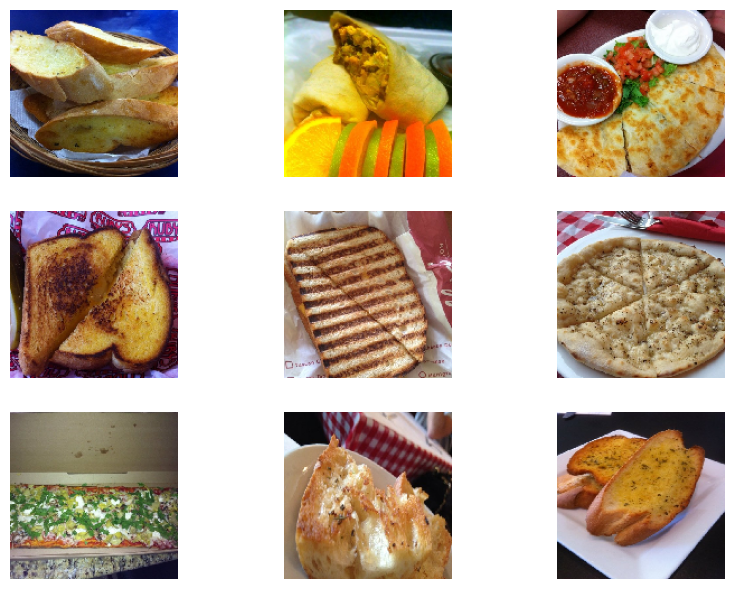

In [ ]:
fig = plt.figure(figsize=(10,10))
for i in range(9):
  ax = fig.add_subplot(4,3,i+1)

  fp = f'{DATADIR}/{CATEGORIES[0]}/{select_bread[i]}'

  fn = load_img(fp, target_size=(150,150))

  plt.imshow(fn, )
  plt.axis('off')

### Splitting the Data

In [ ]:
# Create separate list variables for training data, one for the images, one for their corresponding category
X_train = []
y_train = []

np.random.shuffle(training_data) # Data is usually randomly shuffled

In [ ]:
for image, label in training_data:
  X_train.append(image)
  y_train.append(label)

In [ ]:
# Conduct the same for the testing data
np.random.shuffle(testing_data)

In [ ]:
X_test = []
y_test = []
for image, label in testing_data:
  X_test.append(image)
  y_test.append(label)

In [ ]:
# Convert from lists to numpy array, as easier to work with.
X_train = np.array(X_train)
X_test = np.array(X_test)
X_train.shape, X_test.shape

((3203, 150, 150, 3), (1094, 150, 150, 3))

In [ ]:
# Convert labels from string list to integer.
y_train = pd.DataFrame(y_train, columns=['Label'], dtype=object)
y_test = pd.DataFrame(y_test, columns=['Label'], dtype=object)

In [ ]:
y_train.Label.value_counts(normalize=True)

,proportion
Label,
Soup,0.468311
Bread,0.310334
Vegetable-Fruit,0.221355


In [ ]:
y_test.Label.value_counts(normalize=True)

,proportion
Label,
Soup,0.457038
Bread,0.330896
Vegetable-Fruit,0.212066


In [ ]:
# Image data preprocessing
# Normalising the image pixel values to range between 0 and 1 so the numbers are smaller, thus computation is  easier and faster.
# As the pixel ranges from 0 to 256, apart from 0 the range is 255, thus dividing by 255 will convert the images to the desired range.
X_train = X_train/255.0
X_test = X_test/255.0

Confirm conversion to between 0 and 1.

In [ ]:
X_train.min(), X_train.max()

(np.float64(0.0), np.float64(1.0))

In [ ]:
X_test.min(), X_test.max()

(np.float64(0.0), np.float64(1.0))

Converting labels in integer format to one-hot encoded vectors, to enable categorical classifiication.

In [ ]:
# Store a list of encoded labels
y_train_encoded = []

for label_name in y_train.Label:
  if label_name=="Bread":
    y_train_encoded.append(0)
  if label_name=="Soup":
    y_train_encoded.append(1)
  if label_name=="Vegetable-Fruit":
    y_train_encoded.append(2)

In [ ]:
# Convert to one-hot encoded vectors
y_train_encoded = to_categorical(y_train_encoded)
y_train_encoded

array([[0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [ ]:
y_train_encoded.shape, X_train.shape

((3203, 3), (3203, 150, 150, 3))

In [ ]:
y_test_encoded = []

for label_name in y_test.Label:
  if label_name=="Bread":
    y_test_encoded.append(0)
  if label_name=="Soup":
    y_test_encoded.append(1)
  if label_name=="Vegetable-Fruit":
    y_test_encoded.append(2)

In [ ]:
y_test_encoded = to_categorical(y_test_encoded)
y_test_encoded

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.]])

In [ ]:
y_test_encoded.shape, X_test.shape

((1094, 3), (1094, 150, 150, 3))

### Training the Model

In [ ]:
# Removes previous models
backend.clear_session()

In [ ]:
# Import Python random library
import random

In [ ]:
# Set random seed for different sources of stochsticity, important for reproducability
seed = 42
random.seed(seed)
np.random.seed(seed) # numpy
tf.random.set_seed(seed) # tensorflow

In [ ]:
# Simple convoluted neural network
# Creates a sequential model in Keras. A sequential model is a linear stack of layers, each layer has one input tensor and one output tensor.
# Common starting point for image classification models, adding layers one after another, such model architecture flows in a straight line.
model = Sequential() # Call an empty python list using sequential, assigning it to the variable, model.

# Define the shape of the input images, based of pixels and colour (RGB = 3, Greyscale = 1, RGBA = 4, Speicalised Multiframe Images, like MRI = 4+)
model.add(Input(shape=(150, 150, 3))) # Only needed in the first layer; following layers infer their input shape from the previous layer.

# Add a 2D convolutional layer as the first layer in the CNN model, setting hyperparameters.
# Convolutional layers applies filters like "small sliding windows" over the input image to detect local fetaures (edges, corners, textures etc)
model.add(Conv2D(64 # No. of fliters
                 ,(3, 3) # Kernel filter size (3x3 is standard, balancing efficiency with ablity to capturee spatial patterns. Larger sizes, 5x5 & 7x7, capture more context but risk overfitting.)
                 ,activation = 'relu' # Applies Rectified Linear Unit function to outputs of convoltuion, helping netwrok learn more complex non linear relationships
                 ,padding = 'same')) # Ensures output feature map has the same spatial dimesnions (150 x 150) as the input
# Add a pooling layer to reduce the spatial size (hieght & width) of the feature maps.
# Helps with downsampling (improves network computational efficieny), translation variance (small shifts in the image will not change the pooled feature too much), overfitting (reduces chance of noise influence, as fewer parameters in later layers)
model.add(MaxPooling2D(padding='same')) # Max pooling reduces both height and width by a factor of 2.

model.add(Conv2D(32, (3, 3), activation = 'relu', padding = 'same')) # Add a 2D convolutional layer to the model, setting hyperparameters
model.add(MaxPooling2D(padding='same')) # Add a pooling layer to the model

model.add(Conv2D(32, (3, 3), activation = 'relu', padding = 'same'))
model.add(MaxPooling2D(padding='same'))

# Flattening, flattens output from the previous layer into a 1-dimensional vector. Helps in this transition by reshaping the data.
model.add(Flatten()) # Often necessary when transitioning from convolutional layers to fully connected dense layers, as dense layers require 1-dimensinsional input. Dense layers learn class decision boundaries and their neurons connect to all flatten layer outputs.

# Classifier head of the CNN, takes extracted features and makes final predictions. The layer acts like a feature combiner, taking all the learnt abstract features in the Conv layers and mixes them into useful representations to help classification.
model.add(Dense(100, activation='relu')) # Hyperparameters: No. of neurons in the layer (The more neurons, the more capacity to learn patterns, but also the greater risk of overfitting), ReLU introduces non linearity, so layer can learn complex decision boundaries.

# Output layer - makes the decision and outputs probabilities for each class.
model.add(Dense(3, activation='softmax')) # Hyperparametrs: No. of neurons, which corresponds to no. of categories, 'softmax' converts raw outputs into probabilities ensuring probabilities across all classes sum to 1.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 11552)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     1,155,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185,107 (4.52 MB)

 Trainable params: 1,185,107 (4.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Next instantiate an optimiser. Research has shown SGD learning rate combined with momentum (especioally = 0.9) delivers high accuracy and generability for image classification tasks
opt = SGD(learning_rate=0.01, momentum=0.9) # Research shown learnig rate should be 10 to 50 times than that for ADAM optimiser. ADAM LR is 10^-3.

In [ ]:
# Compile model, setting loss function, optimiser, metrics and call backs
model.compile(optimizer=opt, loss = 'categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 11552)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     1,155,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185,107 (4.52 MB)

 Trainable params: 1,185,107 (4.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks to help with model training: early stopping, model checkpoint . Useful to prevent overfitting and needless model training with no valuable increase in performance.
es = EarlyStopping(monitor='val_loss', # Monitor - what value you want to track and if stops improving, stop training. Can validation loss, validation accuracy etc.
                   mode='min', # Mode - depends on what is being monitored. For validation loss, the lower the value the better the performance, thus "min". Hence for accurancy it would be "max"
                   verbose=1, # Verbosity - how much information gets printed to thee console while early stopping. "0" - Silent, "1" - Informative
                   patience=5) # How many epochs (a full pass through training dataset) should I wait when the monitored metric does not improve before I stop training. Important as performance may not improve immediately
mc = ModelCheckpoint('best_model.h5', # Path file name for the best model. h5 is an efficient and fast date storage format, used by multiple libraries.
                     monitor='val_accuracy',
                     mode='max',
                     verbose=1,
                     save_best_only=True) # "True" stops model saving every epoch, instead only saves the best model with respect to the monitored metric, in this case validation accuracy.

In [ ]:
# Training the model - ensure to run on GPU. Save to history variable, so can plot later
history = model.fit(X_train, # x data (features/inputs)
                    y_train_encoded, # one hot encoded y data (labels/outputs)
                    batch_size=32, # how many training samples the model processes before updating the weights once. Data processed in mini batches for efficiency
                    epochs=60, # Can set as high as possible as early stopping callback used
                    validation_split=0.1, # Splits data into validation and training by represented figure. 10% usually sufficient. Validation dataset used to fine-tune and find the best set of hyperparamters
                    callbacks=[es, mc]) # List callbacks for the model to utilise

Epoch 1/60
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4467 - loss: 1.0698
Epoch 1: val_accuracy improved from -inf to 0.50779, saving model to best_model.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.4468 - loss: 1.0697 - val_accuracy: 0.5078 - val_loss: 1.0153
Epoch 2/60
89/91 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5041 - loss: 0.9820
Epoch 2: val_accuracy did not improve from 0.50779
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5046 - loss: 0.9813 - val_accuracy: 0.4019 - val_loss: 1.0905
Epoch 3/60
89/91 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4709 - loss: 1.0283
Epoch 3: val_accuracy improved from 0.50779 to 0.60436, saving model to best_model.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.4719 - loss: 1.0266 - val_accuracy: 0.6044 - val_loss: 0.7857
Epoch 4/60
89/91 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5859 - loss: 0.8496
Epoch 4: val_accuracy improved from 0.60436 to 0.60748, saving model to best_model.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5862 - loss: 0.8488 - val_accuracy: 0.6075 - val_loss: 0.8721
Epoch 5/60
89/91 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6040 - loss: 0.8180
Epoch 5: val_accuracy improved from 0.60748 to 0.62617, saving model to best_model.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6043 - loss: 0.8169 - val_accuracy: 0.6262 - val_loss: 0.8501
Epoch 6/60
89/91 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6162 - loss: 0.7921
Epoch 6: val_accuracy did not improve from 0.62617
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6164 - loss: 0.7913 - val_accuracy: 0.6262 - val_loss: 0.8599
Epoch 7/60
89/91 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6618 - loss: 0.7208
Epoch 7: val_accuracy improved from 0.62617 to 0.66355, saving model to best_model.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6623 - loss: 0.7197 - val_accuracy: 0.6636 - val_loss: 0.8543
Epoch 8/60
89/91 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6790 - loss: 0.7030
Epoch 8: val_accuracy did not improve from 0.66355
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6794 - loss: 0.7017 - val_accuracy: 0.6449 - val_loss: 0.9848
Epoch 8: early stopping


In [ ]:
model.load_weights("/content/best_model.h5")

### Model Predictions

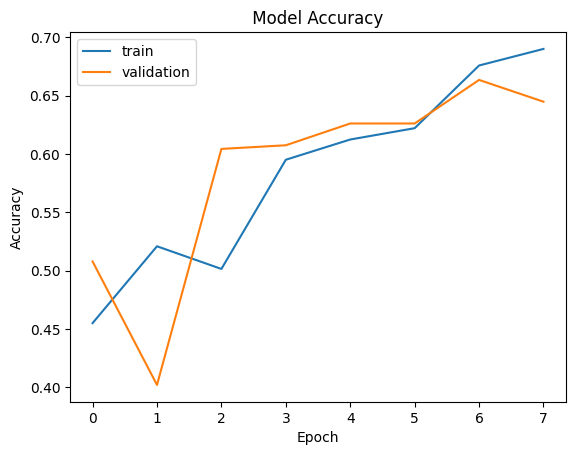

In [ ]:
# Plot model accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title(' Model Accuracy ')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')

Methods to improve generalisability of the model, such as the validation accuracy: Add dropouts, batch normalisation, data augmentation like random rotations and translations of the image data, change image brightness, deepen the model such that it can learn more complex features. These help to iterate and find the best hyperparameters. Once finding the best hyperparameters and we are confident that our model is the one that is going to generalise perfectly to the on-scene data, then we can call model.evaluate()

In [ ]:
# Use test data to evaluate the model
model.evaluate(X_test, y_test_encoded)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6548 - loss: 0.8405


[0.8349029421806335, 0.6581352949142456]

Accuracy similar to that of the validation set. If test evaluation was much less than the validation, it would suggest hyperparameters are overfitted to the validation set.

Plot Confusion Matricies

In [ ]:
# Scikit-learn has good functions to plot confusion matricies and classification reports
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Call predictions from the model
pred = model.predict(X_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [ ]:
# Check shape of prediction list
pred.shape

(1094, 3)

In [ ]:
# Check first prediction
pred[0]

array([1.7540193e-01, 8.2420868e-01, 3.8936775e-04], dtype=float32)

From viewing can see model predicts soup (largest probability) for first instance.

In [ ]:
# Change prediction list to show just the category index of the maximum probability
pred = np.argmax(pred, axis=1) # Need to set "axis", columns axis = 1. Want to look across columns to see which columns (category index) has the maximum probability

In [ ]:
# Check shape again
pred.shape

(1094,)

Can see prediction list had reduced to 1 column.

In [ ]:
pred[0].item()

1

Returns categorical index, as wanted. Now repeat for one hot encoded y values.

In [ ]:
y_true = np.argmax(y_test_encoded, axis=1)
y_true

array([0, 0, 0, ..., 1, 2, 1])

In [ ]:
y_true[0].item()

0

In [ ]:
# Classification Report
print(classification_report(y_true, pred))

              precision    recall  f1-score   support

           0       0.63      0.29      0.39       362
           1       0.65      0.84      0.74       500
           2       0.68      0.84      0.75       232

    accuracy                           0.66      1094
   macro avg       0.66      0.66      0.63      1094
weighted avg       0.65      0.66      0.63      1094



Poor recall for bread, high recall for soup and vegetables and fruit. Poor precision for all categories.

In [ ]:
y_train.Label.value_counts(normalize=True)

,proportion
Label,
Soup,0.468311
Bread,0.310334
Vegetable-Fruit,0.221355


Soup is over prsented as the majority class, with higher metircs thus model may be biased towards Soup. Hence model may be misidentifying bread for soup.


Vegetable & Fruit are the minoirty class, thus this could explain its higher precision and recall, or could suggest vegatable & fruit are easier to identify.

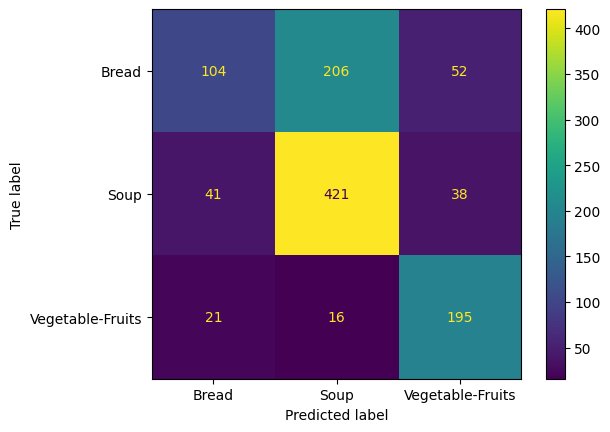

In [ ]:
# Confusuion Matrix - can usually provide further insight.
ConfusionMatrixDisplay.from_predictions(y_true, pred, display_labels=['Bread', 'Soup', 'Vegetable-Fruits'])

As believed the model is heavily biased towards soup, misclassifying bread as soup, shown by 206 misclassifications. Next need to check some misclassifyed examples to see if there is any data which could be misleading the model.

### Regularisation

Adding regularisation and training a new neural network to see if we can improve the accuracy and reduce the misclassification. Regularisation refers to techniques that constrain or penalise a model’s complexity so it generalises better to unseen data encouraging the network to learn simpler, more general patterns that work well on new data.

In [ ]:
backend.clear_session()
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
model_2 = Sequential()

model_2.add(Input(shape=(150, 150, 3)))

model_2.add(Conv2D(256, (5,5), padding='same', activation='relu')) # Increase the kernel size so the receptive field of the first layer is larger
model_2.add(MaxPooling2D(strides = (2,2))) # Padding default is "valid". "Strides" sets how far the pooling window moves each step. 2x2 moves 2 pixels at a time in both height and width
model_2.add(Dropout(0.25)) # Regularisation technique to reduce overfitting

# "0.25" is the rate which randomly sets a fraction of neurons to 0 (ignores them) on each forward pass.
# This prevents the network from relying too heavily on specific neurons or paths.
# As a result, the network is forced to learn redundant, distributed representations.

model_2.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model_2.add(MaxPooling2D(strides = (2,2)))
model_2.add(Dropout(0.25))

model_2.add(Conv2D(32, (3,3), padding='same', activation='relu'))
model_2.add(MaxPooling2D(strides = (2,2)))
model_2.add(Dropout(0.25))

model_2.add(Flatten())

model_2.add(Dense(64, activation='relu'))

model_2.add(Dense(32, activation='relu'))

model_2.add(Dense(3, activation='softmax'))

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 256)  │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       663,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851,235 (3.25 MB)

 Trainable params: 851,235 (3.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define optimiser as ADAM in this model instead of SGD
optimiser = Adam(learning_rate = 0.001) # Learning rate 10^-3 as previously mentioned is standard.

model_2.compile(optimizer = optimiser, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
mc = ModelCheckpoint('best_model_2.h5', monitor = 'val_accuracy', mode='max', verbose=1, save_best_only=True)

In [ ]:
history_2 = model_2.fit(X_train, y_train_encoded,
                        epochs = 60,
                        batch_size = 32,
                        validation_split = 0.1,
                        callbacks = [es, mc])

Epoch 1/60
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.4722 - loss: 1.0375
Epoch 1: val_accuracy improved from -inf to 0.61059, saving model to best_model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 20s 220ms/step - accuracy: 0.4725 - loss: 1.0370 - val_accuracy: 0.6106 - val_loss: 0.8167
Epoch 2/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5892 - loss: 0.8524
Epoch 2: val_accuracy improved from 0.61059 to 0.62305, saving model to best_model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.5894 - loss: 0.8516 - val_accuracy: 0.6231 - val_loss: 0.7804
Epoch 3/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6120 - loss: 0.7844
Epoch 3: val_accuracy did not improve from 0.62305
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.6121 - loss: 0.7840 - val_accuracy: 0.6044 - val_loss: 0.7882
Epoch 4/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6555 - loss: 0.7173
Epoch 4: val_accuracy did not improve from 0.62305
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.6557 - loss: 0.7169 - val_accuracy: 0.5919 - val_loss: 0.9010
Epoch 5/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6770 - loss: 0.6819
Epoch 5: val_accuracy improved from 0.62305 to 0.69782, saving model to best_model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.6772 - loss: 0.6814 - val_accuracy: 0.6978 - val_loss: 0.6920
Epoch 6/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.7294 - loss: 0.5882
Epoch 6: val_accuracy did not improve from 0.69782
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.7293 - loss: 0.5883 - val_accuracy: 0.6916 - val_loss: 0.6888
Epoch 7/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.7894 - loss: 0.5015
Epoch 7: val_accuracy did not improve from 0.69782
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - accuracy: 0.7893 - loss: 0.5014 - val_accuracy: 0.6667 - val_loss: 0.7797
Epoch 8/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8038 - loss: 0.4608
Epoch 8: val_accuracy did not improve from 0.69782
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.8040 - loss: 0.4604 - val_accuracy: 0.6885 - val_loss: 0.7902
Epoch 9/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7987 - loss: 0.4690
Epoch 9: val_accuracy improved f

91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.7991 - loss: 0.4679 - val_accuracy: 0.7352 - val_loss: 0.6289
Epoch 10/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8660 - loss: 0.3240
Epoch 10: val_accuracy did not improve from 0.73520
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.8660 - loss: 0.3240 - val_accuracy: 0.7040 - val_loss: 0.6985
Epoch 11/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8801 - loss: 0.2868
Epoch 11: val_accuracy did not improve from 0.73520
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.8802 - loss: 0.2866 - val_accuracy: 0.7227 - val_loss: 0.7172
Epoch 12/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9010 - loss: 0.2677
Epoch 12: val_accuracy did not improve from 0.73520
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.9008 - loss: 0.2678 - val_accuracy: 0.7009 - val_loss: 0.7030
Epoch 13/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9054 - loss: 0.2176
Epoch 13: val_accuracy d

### Model Evaluation

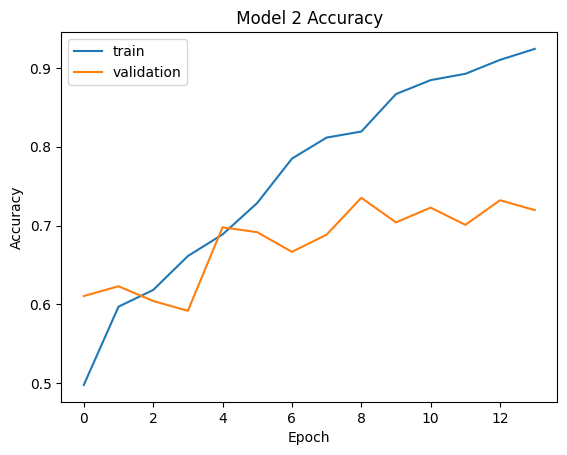

In [ ]:
# Plot Model 2 Accuracy
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.title(' Model 2 Accuracy ')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')

Validation accuracy improved from the previous model but not by a significant margin. Given the accuracy massively improved in this model, it suggests with further regualrisation and increasing the models capcity by increasing the number of layers and parameters.

Given the large gap between the accuracy and validation accuracy, it suggest the model extremely overfitting. To solve, could increase the dropout rate, perform data augmentation, change the learning rate schedule.

In [ ]:
# Evaluate second model on test data
model_2.evaluate(X_test, y_test_encoded)

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.7409 - loss: 0.8084


[0.8381761908531189, 0.7221206426620483]

Accuracy improved, validation loss worsened compared to the first model on the test dataset.

In [ ]:
# Classification Report Model 2
pred = model_2.predict(X_test)
pred = np.argmax(pred, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

print(classification_report(y_true, pred))

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
              precision    recall  f1-score   support

           0       0.70      0.48      0.57       362
           1       0.68      0.89      0.77       500
           2       0.88      0.72      0.80       232

    accuracy                           0.72      1094
   macro avg       0.76      0.70      0.71      1094
weighted avg       0.73      0.72      0.71      1094



Bread precision and recall low again, but improved significantly.

Soup precision and recall improved but not significantly.

Vegeatable-Fruits precision improved signifcantly and recall worsened significantly.

Could try to improve by adding bread data to balance the data set or increase the bread allocation through targeted augmentation.

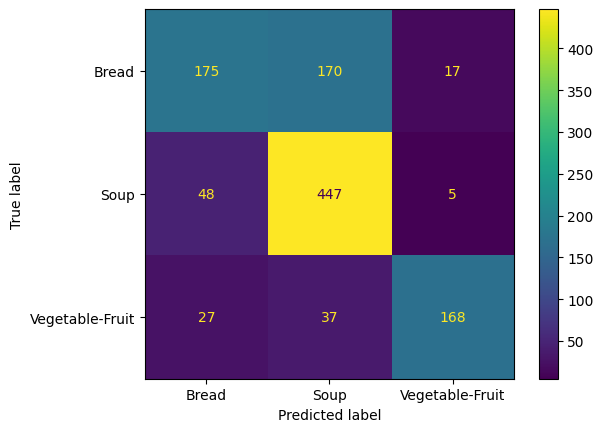

In [ ]:
# Confusion Matrix Model 2
ConfusionMatrixDisplay.from_predictions(y_true, pred, display_labels=CATEGORIES)

Still a very large number of breads are misclassified as soup and some soup is misclassified as bread.

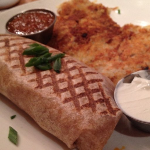

In [ ]:
# View some test images
cv2_imshow(X_test[1]*255)

In [ ]:
# View image label
y_test.Label[1]

'Bread'

In [ ]:
# View model prediction
res = model_2.predict(X_test[1].reshape((1, 150, 150, 3))) # Need to remember to reshape
res

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 652ms/step


array([[7.3983455e-01, 2.5961974e-01, 5.4571015e-04]], dtype=float32)

Model is 74% confident it is bread. Bread is correctly identified.

In [ ]:
np.argmax(res).item()

0

To attempt to further improve the model need to use data augmentation, perspective warping and shearing to change the perspective of the images, alter the brightness.

Could also use pre trained models and use transfer learning so weights do not need to be trained from scratch.

Another approach could be to add other methods that would stabilise the training of the deep neural netwroks such as batch normalisation.

If we combine all these we can potentially improve the test set accuracy of the model to more than 80 or 90%.

### Further Regularisation

In [ ]:
backend.clear_session()
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
model_3 = Sequential()

model_3.add(Input(shape=(150, 150, 3)))

model_3.add(Conv2D(256, (5,5), padding='same', activation='relu'))
model_3.add(MaxPooling2D(strides = (2,2)))
model_3.add(Dropout(0.4)) # Increase dropout rate to reduce overfitting

model_3.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model_3.add(MaxPooling2D(strides = (2,2)))
model_3.add(Dropout(0.4))

model_3.add(Conv2D(32, (3,3), padding='same', activation='relu'))
model_3.add(MaxPooling2D(strides = (2,2)))
model_3.add(Dropout(0.4))

model_3.add(Flatten())

model_3.add(Dense(64, activation='relu'))

model_3.add(Dense(32, activation='relu'))

model_3.add(Dense(3, activation='softmax'))

model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 256)  │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       663,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851,235 (3.25 MB)

 Trainable params: 851,235 (3.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimiser = Adam(learning_rate = 0.001)

model_3.compile(optimizer = optimiser, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
mc = ModelCheckpoint('best_model_2.h5', monitor = 'val_accuracy', mode='max', verbose=1, save_best_only=True)

In [ ]:
history_3 = model_3.fit(X_train, y_train_encoded,
                        epochs = 60,
                        batch_size = 32,
                        validation_split = 0.1,
                        callbacks = [es, mc])

Epoch 1/60
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.4301 - loss: 1.0903
Epoch 1: val_accuracy improved from -inf to 0.53894, saving model to best_model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 21s 170ms/step - accuracy: 0.4303 - loss: 1.0900 - val_accuracy: 0.5389 - val_loss: 0.9554
Epoch 2/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5321 - loss: 0.9331
Epoch 2: val_accuracy improved from 0.53894 to 0.61371, saving model to best_model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.5328 - loss: 0.9319 - val_accuracy: 0.6137 - val_loss: 0.8212
Epoch 3/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6013 - loss: 0.7976
Epoch 3: val_accuracy improved from 0.61371 to 0.61682, saving model to best_model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.6014 - loss: 0.7973 - val_accuracy: 0.6168 - val_loss: 0.7832
Epoch 4/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6205 - loss: 0.7512
Epoch 4: val_accuracy improved from 0.61682 to 0.62928, saving model to best_model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.6208 - loss: 0.7508 - val_accuracy: 0.6293 - val_loss: 0.7542
Epoch 5/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6477 - loss: 0.7261
Epoch 5: val_accuracy improved from 0.62928 to 0.65732, saving model to best_model_2.h5


...

91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.6940 - loss: 0.6644 - val_accuracy: 0.7072 - val_loss: 0.6834
Epoch 7/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7299 - loss: 0.6094
Epoch 7: val_accuracy improved from 0.70717 to 0.71028, saving model to best_model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.7300 - loss: 0.6090 - val_accuracy: 0.7103 - val_loss: 0.6805
Epoch 8/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7723 - loss: 0.5254
Epoch 8: val_accuracy improved from 0.71028 to 0.73520, saving model to best_model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.7723 - loss: 0.5252 - val_accuracy: 0.7352 - val_loss: 0.6518
Epoch 9/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8000 - loss: 0.4765
Epoch 9: val_accuracy did not improve from 0.73520
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.8001 - loss: 0.4760 - val_accuracy: 0.7196 - val_loss: 0.6742
Epoch 10/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7777 - loss: 0.4810
Epoch 10: val_accuracy did not improve from 0.73520
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.7778 - loss: 0.4809 - val_accuracy: 0.6791 - val_loss: 0.7200
Epoch 11/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8043 - loss: 0.4555
Epoch 11: val_accuracy improved from 0.73520 to 0.74766, saving model to best_model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.8049 - loss: 0.4544 - val_accuracy: 0.7477 - val_loss: 0.6355
Epoch 12/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8476 - loss: 0.3618
Epoch 12: val_accuracy did not improve from 0.74766
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.8480 - loss: 0.3610 - val_accuracy: 0.7383 - val_loss: 0.6651
Epoch 13/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8670 - loss: 0.3203
Epoch 13: val_accuracy improved from 0.74766 to 0.76012, saving model to best_model_2.h5


91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.8674 - loss: 0.3196 - val_accuracy: 0.7601 - val_loss: 0.6662
Epoch 14/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8949 - loss: 0.2518
Epoch 14: val_accuracy did not improve from 0.76012
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.8950 - loss: 0.2516 - val_accuracy: 0.7290 - val_loss: 0.7031
Epoch 15/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8962 - loss: 0.2499
Epoch 15: val_accuracy did not improve from 0.76012
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.8962 - loss: 0.2498 - val_accuracy: 0.7539 - val_loss: 0.7177
Epoch 16/60
90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8977 - loss: 0.2539
Epoch 16: val_accuracy did not improve from 0.76012
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.8978 - loss: 0.2536 - val_accuracy: 0.7383 - val_loss: 0.7554
Epoch 16: early stopping


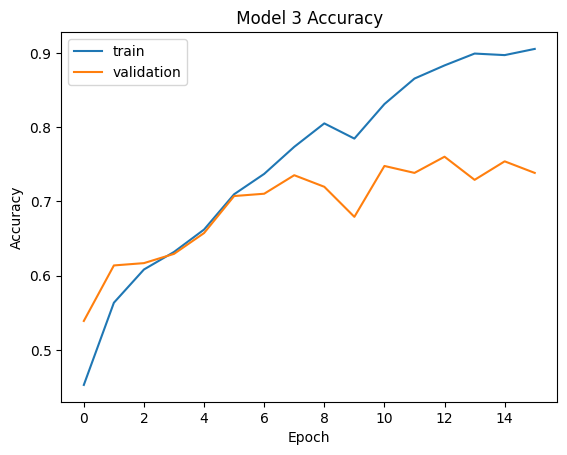

In [ ]:
# Plot Model 3 Accuracy
plt.plot(history_3.history['accuracy'])
plt.plot(history_3.history['val_accuracy'])
plt.title(' Model 3 Accuracy ')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')

In [ ]:
model_3.evaluate(X_test, y_test_encoded)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7903 - loss: 0.7017


[0.6990804672241211, 0.7797074913978577]

In [ ]:
pred = model_3.predict(X_test)
pred = np.argmax(pred, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

print(classification_report(y_true, pred))

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
              precision    recall  f1-score   support

           0       0.68      0.75      0.71       362
           1       0.81      0.82      0.82       500
           2       0.93      0.73      0.82       232

    accuracy                           0.78      1094
   macro avg       0.80      0.77      0.78      1094
weighted avg       0.79      0.78      0.78      1094



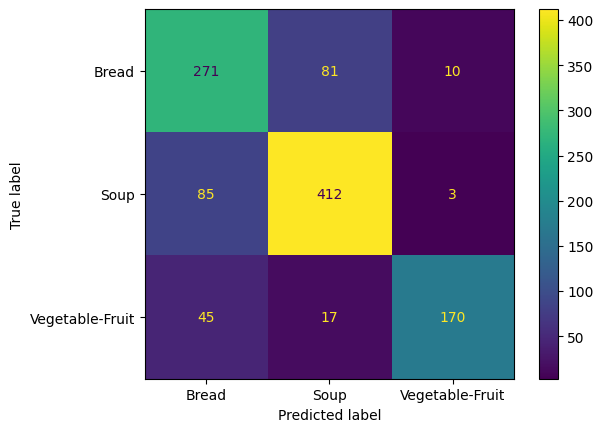

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_true, pred, display_labels=CATEGORIES)

Model 3 the best so far. Validation accuracy and f1 score significantly improved with the increased dropout rate from the previous models.

Soup is solid and balanced, bread is significantly improved recall but less precise. Veg & Fruit is extremely precise but under detected.

Model still shows class specific weaknesses meaning more data variety or stronger feature extraction is needed.

Much less bread is classified as soup, but more soup is being misclassified as bread.